In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_3080.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_3357.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_0983.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_1124.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_3829.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_3515.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_1324.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_4162.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_scc_0771.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_scc_0707.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_scc_3093.jpg
/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled/oral_normal_0952.jpg
/kaggle/input

In [2]:
!pip install torch torchvision matplotlib numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from torch.cuda.amp import autocast, GradScaler
import os

In [4]:
# Set environment to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [5]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [6]:
# Define dataset class for SimCLR pre-training
class OralCancerSimCLRDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.images = [os.path.join(data_path, fname) for fname in os.listdir(data_path) if fname.endswith('.jpg')]
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert('RGB')
        
        # Infer label from filename (for downstream, ignored in pre-training)
        fname = os.path.basename(img_path).lower()
        if 'scc' in fname or 'cancer' in fname:
            label = 1
        elif 'normal' in fname or 'non' in fname:
            label = 0
        else:
            raise ValueError(f"Cannot infer label from filename: {fname}")
        
        if self.transform:
            img1 = self.transform(img)  # First augmented view
            img2 = self.transform(img)  # Second augmented view
            return img1, img2, label
        return img, label  # Return single img for downstream (PIL)

In [7]:
# Define wrapper for downstream task (single image + label) - Simplified since base uses None transform
class DownstreamWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        item = self.subset[idx]
        if len(item) == 3:  # From aug dataset, ignore img2
            img, _, label = item
        else:  # From base (PIL, label)
            img, label = item
        if self.transform:
            img = self.transform(img)
        return img, label

In [8]:
# Define SimCLR model
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = base_encoder
        self.encoder.classifier = nn.Identity()  # Remove the final classifier to get 1280 features
        self.feature_dim = 1280  # EfficientNet-B0 feature dim after avgpool
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)  # (batch, 1280)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)  # L2 normalization

In [9]:
# Define NT-Xent loss
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # [2N, projection_dim]
    sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    # Correct labels for positive pairs
    labels = torch.cat([torch.arange(batch_size, 2 * batch_size), torch.arange(batch_size)]).to(z1.device)
    # Mask self-similarities (diagonal) to -inf
    mask = torch.eye(2 * batch_size, device=z1.device).bool()
    sim_matrix = sim_matrix.masked_fill(mask, -float('inf'))
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [10]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

downstream_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# Load dataset for pre-training (with aug)
data_path = '/kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled'
if not os.path.exists(data_path):
    raise ValueError(f"Data path {data_path} does not exist. Run '!ls /kaggle/input/' to check.")
print(f"Loading dataset from {data_path}")

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Loading dataset from /kaggle/input/oral-cancer-dataset-all-unlabeled/all unlabeled
Found 10002 images


In [12]:
# Split indices
pretrain_size = int(0.8 * len(aug_dataset))  # ~8001
remaining_size = len(aug_dataset) - pretrain_size  # ~2001
pretrain_split, remaining_split = random_split(aug_dataset, [pretrain_size, remaining_size])
pretrain_indices = pretrain_split.indices
remaining_indices = remaining_split.indices
print(f"Pretrain dataset size: {len(pretrain_indices)}")
print(f"Remaining dataset size: {len(remaining_indices)}")

Pretrain dataset size: 8001
Remaining dataset size: 2001


In [13]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [14]:
# Create base dataset without transform (for downstream, t-SNE, test - PIL images)
base_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=None)

In [15]:
# Downstream dataset (same 80% indices, but from base)
downstream_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
downstream_dataset = DownstreamWrapper(downstream_subset, downstream_transform)
train_size = int(0.7 * len(downstream_dataset))  # ~5601
val_size = len(downstream_dataset) - train_size  # ~2400
downstream_train_split, downstream_val_split = random_split(downstream_dataset, [train_size, val_size])

In [16]:
# Downstream loaders
train_loader_downstream = DataLoader(downstream_train_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader_downstream = DataLoader(downstream_val_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [17]:
# Test loader (20% holdout from base)
test_subset = torch.utils.data.Subset(base_dataset, remaining_indices)
test_dataset = DownstreamWrapper(test_subset, downstream_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [18]:
# Initialize SimCLR model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_encoder = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model = SimCLR(base_encoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scaler = torch.amp.GradScaler(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


In [19]:
# Clear GPU cache before training (Fix OOM)
torch.cuda.empty_cache()

In [20]:
# Pre-training loop
num_epochs = 100
pretrain_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Pretrain Epoch {epoch+1}/{num_epochs}"):
        img1, img2, _ = batch
        img1, img2 = img1.to(device), img2.to(device)
        optimizer.zero_grad()
        with autocast():  # Mixed precision to save memory
            z1 = model(img1)
            z2 = model(img2)
            loss = nt_xent_loss(z1, z2)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    torch.cuda.empty_cache()  # Clear cache after each epoch

Pretrain Epoch 1/100:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_36/3686234825.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed precision to save memory
Pretrain Epoch 1/100: 100%|██████████| 250/250 [02:16<00:00,  1.83it/s]


Epoch 1, Loss: 2.6311


Pretrain Epoch 2/100: 100%|██████████| 250/250 [01:44<00:00,  2.40it/s]


Epoch 2, Loss: 2.3516


Pretrain Epoch 3/100: 100%|██████████| 250/250 [01:42<00:00,  2.45it/s]


...

Epoch 98, Loss: 2.2077


Pretrain Epoch 99/100: 100%|██████████| 250/250 [01:40<00:00,  2.48it/s]


Epoch 99, Loss: 2.2091


Pretrain Epoch 100/100: 100%|██████████| 250/250 [01:42<00:00,  2.45it/s]

Epoch 100, Loss: 2.2067


In [21]:
# Save pretrained model
torch.save(model.state_dict(), 'simclr_pretask_efficientnetb0.pth')

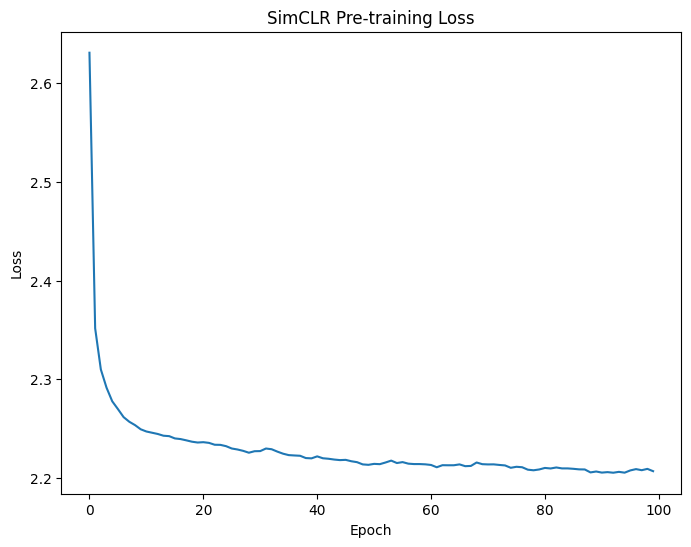

In [22]:
# Plot pre-training loss
plt.figure(figsize=(8, 6))
plt.plot(pretrain_losses)
plt.title('SimCLR Pre-training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('pretrain_loss.png')
plt.show()

In [23]:
# t-SNE Visualization
model.eval()

SimCLR(
  (encoder): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activa

Extracting features for t-SNE: 100%|██████████| 251/251 [00:30<00:00,  8.23it/s]


Running t-SNE on pretrain dataset features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 8001 samples in 0.005s...
[t-SNE] Computed neighbors for 8001 samples in 2.223s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8001
[t-SNE] Computed conditional probabilities for sample 2000 / 8001
[t-SNE] Computed conditional probabilities for sample 3000 / 8001
[t-SNE] Computed conditional probabilities for sample 4000 / 8001
[t-SNE] Computed conditional probabilities for sample 5000 / 8001
[t-SNE] Computed conditional probabilities for sample 6000 / 8001
[t-SNE] Computed conditional probabilities for sample 7000 / 8001
[t-SNE] Computed conditional probabilities for sample 8000 / 8001
[t-SNE] Computed conditional probabilities for sample 8001 / 8001
[t-SNE] Mean sigma: 7.369369
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.941429
[t-SNE] KL divergence after 1000 iterations: 0.511683


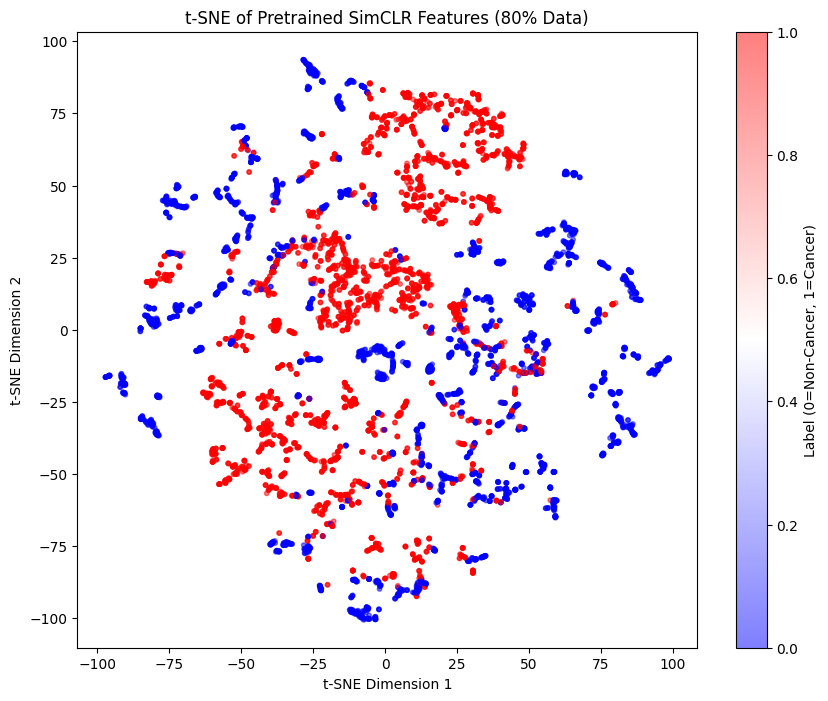

t-SNE plot saved as 'tsne_simclr_pretrain.png'


In [24]:
# Use base_dataset subset for t-SNE (PIL, then transform)
tsne_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
tsne_wrapper = DownstreamWrapper(tsne_subset, transform=downstream_transform)
tsne_loader = DataLoader(tsne_wrapper, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

features = []
labels = []
with torch.no_grad():
    for batch in tqdm(tsne_loader, desc="Extracting features for t-SNE"):
        img, label = batch  # Single img
        img = img.to(device)
        feature = model.encoder(img)
        feature = feature.view(feature.size(0), -1)
        features.append(feature.cpu().numpy())
        labels.append(label.numpy())
features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print("Running t-SNE on pretrain dataset features...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
tsne_features = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='bwr', alpha=0.5, s=10)
plt.colorbar(scatter, label='Label (0=Non-Cancer, 1=Cancer)')
plt.title('t-SNE of Pretrained SimCLR Features (80% Data)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('tsne_simclr_pretrain.png')
plt.show()
print("t-SNE plot saved as 'tsne_simclr_pretrain.png'")

In [25]:
# Downstream classification
num_epochs_cls = 100
classifier = nn.Sequential(
    model.encoder,
    nn.Linear(1280, 2)
).to(device)
for param in classifier[0].parameters():
    param.requires_grad = False  # Freeze encoder
optimizer_cls = torch.optim.Adam(classifier[1].parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
train_losses_cls, val_losses_cls = [], []
train_accs_cls, val_accs_cls = [], []

for epoch in range(num_epochs_cls):
    # Train
    classifier.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for img, label in tqdm(train_loader_downstream, desc=f"Downstream Epoch {epoch+1}/{num_epochs_cls}"):
        img, label = img.to(device), label.to(device)
        optimizer_cls.zero_grad()
        output = classifier(img)
        loss = criterion(output, label)
        loss.backward()
        optimizer_cls.step()
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += label.size(0)
        train_correct += predicted.eq(label).sum().item()
    train_losses_cls.append(train_loss / len(train_loader_downstream))
    train_accs_cls.append(train_correct / train_total)

    # Validate
    classifier.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for img, label in val_loader_downstream:
            img, label = img.to(device), label.to(device)
            output = classifier(img)
            loss = criterion(output, label)
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += label.size(0)
            val_correct += predicted.eq(label).sum().item()
    val_losses_cls.append(val_loss / len(val_loader_downstream))
    val_accs_cls.append(val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Loss {train_losses_cls[-1]:.4f}, Acc {train_accs_cls[-1]:.4f} | Val Loss {val_losses_cls[-1]:.4f}, Acc {val_accs_cls[-1]:.4f}")

Downstream Epoch 1/100: 100%|██████████| 175/175 [00:18<00:00,  9.43it/s]


Epoch 1: Train Loss 0.3128, Acc 0.8554 | Val Loss 0.2204, Acc 0.9025


Downstream Epoch 2/100: 100%|██████████| 175/175 [00:18<00:00,  9.59it/s]


Epoch 2: Train Loss 0.2430, Acc 0.8966 | Val Loss 0.2112, Acc 0.9108


Downstream Epoch 3/100: 100%|██████████| 175/175 [00:18<00:00,  9.59it/s]


...

Epoch 98: Train Loss 0.1415, Acc 0.9416 | Val Loss 0.1721, Acc 0.9392


Downstream Epoch 99/100: 100%|██████████| 175/175 [00:18<00:00,  9.47it/s]


Epoch 99: Train Loss 0.1376, Acc 0.9436 | Val Loss 0.1722, Acc 0.9387


Downstream Epoch 100/100: 100%|██████████| 175/175 [00:18<00:00,  9.56it/s]


Epoch 100: Train Loss 0.1386, Acc 0.9432 | Val Loss 0.1664, Acc 0.9363


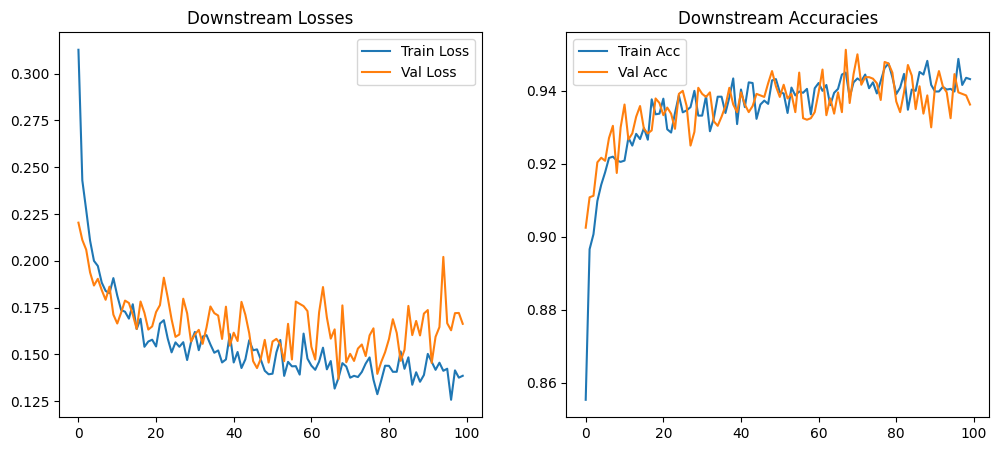

In [26]:
# Plot downstream losses and accuracies
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_cls, label='Train Loss')
plt.plot(val_losses_cls, label='Val Loss')
plt.title('Downstream Losses')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs_cls, label='Train Acc')
plt.plot(val_accs_cls, label='Val Acc')
plt.title('Downstream Accuracies')
plt.legend()
plt.savefig('downstream_metrics.png')
plt.show()

In [27]:
# Test evaluation (optional)
classifier.eval()
test_correct, test_total = 0, 0
y_true, y_pred = [], []
with torch.no_grad():
    for img, label in test_loader:
        img, label = img.to(device), label.to(device)
        output = classifier(img)
        _, predicted = output.max(1)
        test_total += label.size(0)
        test_correct += predicted.eq(label).sum().item()
        y_true.extend(label.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9430


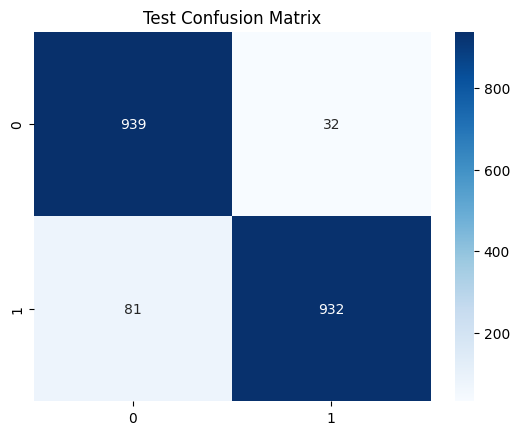

              precision    recall  f1-score   support

  Non-Cancer       0.92      0.97      0.94       971
      Cancer       0.97      0.92      0.94      1013

    accuracy                           0.94      1984
   macro avg       0.94      0.94      0.94      1984
weighted avg       0.94      0.94      0.94      1984



In [28]:
# Confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.savefig('test_cm.png')
plt.show()
print(classification_report(y_true, y_pred, target_names=['Non-Cancer', 'Cancer']))